# Task 1 — Dataset Ingestion, Schema Checks & Preprocessing Design
**Dataset:** `hotel_bookings.csv`
**Goal:** Inspect the data, identify quality issues, flag leakage risks, and design a preprocessing strategy.
**Constraint:** No modelling is performed in this notebook.

---

## Structured Plan

| Step | What | Why |
|---|---|---|
| 1 | Load & sanity-check | Confirm shape, dtypes, memory |
| 2 | Schema annotation | Map every column to domain meaning |
| 3 | Missing-value profiling | Quantify, classify severity, infer mechanism (MCAR/MAR/MNAR) |
| 4 | Data quality checks | Impossible values, duplicates, outliers, inconsistent categories |
| 5 | Leakage & risk flags | Direct leakage, temporal leakage, indirect/post-hoc features |
| 6 | Preprocessing plan | 10-step strategy with justification |
| 7 | Diagnostic visualisations | Support all findings with charts |
| 8 | Verification assertions | Automated checks — must all pass |

**Risks identified upfront:**
- `reservation_status` / `reservation_status_date` — direct target leakage
- Random train/test splits — temporal leakage
- `company` (94% missing), `agent` (14% missing) — imputation strategy needed
- 37% cancellation rate — mild imbalance; accuracy is a misleading metric


## 0. Imports & Configuration

In [1]:
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

DATA_PATH  = Path("hotel_bookings.csv")
OUTPUT_DIR = Path("outputs/task1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Environment ready. Output directory:", OUTPUT_DIR.resolve())


Environment ready. Output directory: /home/user/Predictive-Analytics-Group/outputs/task1


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")
print(f"Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print("First 3 rows:")
df.head(3)


Rows    : 119,390
Columns : 32
Memory  : 109.9 MB

First 3 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


## 2. Schema Inspection

Each column is annotated with its expected type and domain meaning.
Columns flagged with **LEAKAGE RISK** or **INDIRECT RISK** are discussed in depth in Section 5.


In [3]:
COLUMN_METADATA = {
    "hotel":                          ("cat",   "Resort Hotel / City Hotel"),
    "is_canceled":                    ("bin",   "TARGET — 1 = booking cancelled"),
    "reservation_status":             ("cat",   "LEAKAGE RISK — Check-Out / Canceled / No-Show"),
    "reservation_status_date":        ("date",  "LEAKAGE RISK — date of last status change"),
    "lead_time":                      ("int",   "Days between booking and arrival"),
    "arrival_date_year":              ("int",   "Arrival year"),
    "arrival_date_month":             ("cat",   "Arrival month name"),
    "arrival_date_week_number":       ("int",   "ISO week number of arrival"),
    "arrival_date_day_of_month":      ("int",   "Day of month of arrival"),
    "stays_in_weekend_nights":        ("int",   "Weekend nights booked"),
    "stays_in_week_nights":           ("int",   "Weekday nights booked"),
    "adults":                         ("int",   "Number of adults"),
    "children":                       ("float", "Number of children (nullable)"),
    "babies":                         ("int",   "Number of babies"),
    "meal":                           ("cat",   "Meal plan: BB / HB / FB / SC / Undefined"),
    "country":                        ("cat",   "Country of origin (ISO 3166-1)"),
    "market_segment":                 ("cat",   "e.g. Online TA, Offline TA/TO, Direct, Corporate"),
    "distribution_channel":           ("cat",   "Booking channel"),
    "is_repeated_guest":              ("bin",   "1 = returning guest"),
    "previous_cancellations":         ("int",   "Prior cancellations by guest"),
    "previous_bookings_not_canceled": ("int",   "Prior non-cancelled bookings by guest"),
    "reserved_room_type":             ("cat",   "Room type requested (coded A–L)"),
    "assigned_room_type":             ("cat",   "INDIRECT RISK — room assigned; may differ post-booking"),
    "booking_changes":                ("int",   "INDIRECT RISK — changes after booking"),
    "deposit_type":                   ("cat",   "No Deposit / Non Refund / Refundable"),
    "agent":                          ("float", "Travel agent ID (nullable = no agent)"),
    "company":                        ("float", "Company ID (nullable = no company)"),
    "days_in_waiting_list":           ("int",   "Days on waiting list before confirmation"),
    "customer_type":                  ("cat",   "Transient / Contract / Group / Transient-Party"),
    "adr":                            ("float", "INDIRECT RISK — Average Daily Rate"),
    "required_car_parking_spaces":    ("int",   "Car parking spaces requested"),
    "total_of_special_requests":      ("int",   "Count of special requests"),
}

schema_df = pd.DataFrame([
    {
        "column":        col,
        "pandas_dtype":  str(df[col].dtype) if col in df.columns else "—",
        "domain_type":   meta[0],
        "n_unique":      df[col].nunique() if col in df.columns else None,
        "pct_missing":   round(df[col].isna().mean() * 100, 3) if col in df.columns else None,
        "note":          meta[1],
    }
    for col, meta in COLUMN_METADATA.items()
])

schema_df


,column,pandas_dtype,domain_type,n_unique,pct_missing,note
0,hotel,str,cat,2,0.000,Resort Hotel / City Hotel
1,is_canceled,int64,bin,2,0.000,TARGET — 1 = booking cancelled
2,reservation_status,str,cat,3,0.000,LEAKAGE RISK — Check-Out / Canceled / No-Show
3,reservation_status_date,str,date,926,0.000,LEAKAGE RISK — date of last status change
4,lead_time,int64,int,479,0.000,Days between booking and arrival
5,arrival_date_year,int64,int,3,0.000,Arrival year
6,arrival_date_month,str,cat,12,0.000,Arrival month name
7,arrival_date_week_number,int64,int,53,0.000,ISO week number of arrival
8,arrival_date_day_of_month,int64,int,31,0.000,Day of month of arrival
9,stays_in_weekend_nights,int64,int,17,0.000,Weekend nights booked


## 3. Missing Value Assessment

### 3.1 Overall counts


In [4]:
missing = (
    df.isnull().sum()
    .rename("n_missing")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing["pct_missing"] = (missing["n_missing"] / len(df) * 100).round(3)
missing = missing[missing["n_missing"] > 0].sort_values("pct_missing", ascending=False)

def severity(pct):
    if pct < 1:    return "negligible (<1%)"
    elif pct < 5:  return "low (1–5%)"
    elif pct < 20: return "moderate (5–20%)"
    elif pct < 50: return "high (20–50%)"
    else:          return "critical (>50%)"

missing["severity"] = missing["pct_missing"].apply(severity)
missing


,column,n_missing,pct_missing,severity
24,company,112593,94.307,critical (>50%)
23,agent,16340,13.686,moderate (5–20%)
13,country,488,0.409,negligible (<1%)
10,children,4,0.003,negligible (<1%)


### 3.2 Missingness mechanism — is it MCAR, MAR, or MNAR?

In [5]:
# Agent missingness by market_segment (MAR signal)
agent_miss = (
    df.groupby("market_segment")["agent"]
    .apply(lambda s: s.isna().mean() * 100)
    .rename("agent_pct_missing")
    .round(1)
    .reset_index()
    .sort_values("agent_pct_missing", ascending=False)
)

company_miss = (
    df.groupby("market_segment")["company"]
    .apply(lambda s: s.isna().mean() * 100)
    .rename("company_pct_missing")
    .round(1)
    .reset_index()
    .sort_values("company_pct_missing", ascending=False)
)

print("Agent % missing by market_segment:")
print(agent_miss.to_string(index=False))
print()
print("Company % missing by market_segment:")
print(company_miss.to_string(index=False))
print()
print("[INTERPRETATION]")
print("  agent:   missingness strongly varies with market_segment → MAR, not MCAR.")
print("  company: near-100% missing for Direct/OTA channels → MAR; structural absence.")
print("  Both: NULL most likely means 'no agent / no company' (domain default).")
print()
print("Children missingness by hotel type:")
print(df.groupby("hotel")["children"].apply(lambda s: s.isna().sum()))
print("  → 4 missing, all City Hotel; likely data entry omission; impute with 0.")


Agent % missing by market_segment:
market_segment  agent_pct_missing
     Undefined              100.0
      Aviation               89.5
     Corporate               86.8
 Complementary               86.1
        Direct               47.7
        Groups               20.9
 Offline TA/TO                1.6
     Online TA                0.6

Company % missing by market_segment:
market_segment  company_pct_missing
     Undefined                100.0
     Online TA                 99.8
 Offline TA/TO                 99.6
        Direct                 98.3
        Groups                 93.0
 Complementary                 57.9
     Corporate                 15.6
      Aviation                 10.5

[INTERPRETATION]
  agent:   missingness strongly varies with market_segment → MAR, not MCAR.
  company: near-100% missing for Direct/OTA channels → MAR; structural absence.
  Both: NULL most likely means 'no agent / no company' (domain default).

Children missingness by hotel type:
hotel
City Ho

## 4. Data Quality Checks

### 4a. Exact Duplicate Rows

In [6]:
n_dupes = df.duplicated().sum()
pct_dupes = n_dupes / len(df) * 100
print(f"Exact duplicate rows: {n_dupes:,}  ({pct_dupes:.2f}%)")
print()
print("Sample duplicate pair:")
first_dup_mask = df.duplicated(keep=False)
dup_sample = df[first_dup_mask].head(2)
dup_sample


Exact duplicate rows: 31,994  (26.80%)

Sample duplicate pair:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


> **Note:** 26.8% duplicates is striking. Before dropping, investigate whether these
> represent multi-room group bookings (same guest details, different rooms) or
> genuine export artefacts. For modelling, they should be removed to prevent
> the same booking appearing in both train and test sets.


### 4b. Impossible Guest Counts (adults = children = babies = 0)

In [7]:
zero_guests = df[
    (df["adults"] == 0) &
    (df["children"].fillna(0) == 0) &
    (df["babies"] == 0)
]
print(f"Bookings with zero total guests: {len(zero_guests):,}  ({len(zero_guests)/len(df):.3%})")
print()
print("Cancellation status of zero-guest bookings:")
print(zero_guests["is_canceled"].value_counts())
print()
print("Customer type:")
print(zero_guests["customer_type"].value_counts())


Bookings with zero total guests: 180  (0.151%)

Cancellation status of zero-guest bookings:
is_canceled
0    155
1     25
Name: count, dtype: int64

Customer type:
customer_type
Transient          137
Transient-Party     36
Contract             4
Group                3
Name: count, dtype: int64


### 4c. Zero-Night Non-Cancelled Bookings

In [8]:
zero_nights = df[
    (df["stays_in_weekend_nights"] + df["stays_in_week_nights"] == 0) &
    (df["is_canceled"] == 0)
]
print(f"Non-cancelled bookings with 0 total nights: {len(zero_nights):,}  ({len(zero_nights)/len(df):.3%})")
print()
print("These may be same-day arrivals/departures or data errors.")
print(zero_nights[["hotel", "adults", "adr", "customer_type", "deposit_type"]].head(5))


Non-cancelled bookings with 0 total nights: 680  (0.570%)

These may be same-day arrivals/departures or data errors.
            hotel  adults  adr customer_type deposit_type
0    Resort Hotel       2  0.0     Transient   No Deposit
1    Resort Hotel       2  0.0     Transient   No Deposit
167  Resort Hotel       2  0.0     Transient   No Deposit
168  Resort Hotel       1  0.0     Transient   No Deposit
196  Resort Hotel       2  0.0     Transient   No Deposit


### 4d. Negative & Extreme ADR

In [9]:
neg_adr   = df[df["adr"] < 0]
extrem_adr = df[df["adr"] > 5000]

print(f"Negative ADR rows  : {len(neg_adr):,}")
if len(neg_adr):
    print(f"  Values: {neg_adr['adr'].values}")

print(f"ADR > 5000 rows    : {len(extrem_adr):,}")
print()
print("ADR percentile profile:")
pcts = [0, 1, 25, 50, 75, 95, 99, 99.9, 100]
for p in pcts:
    print(f"  {p:5.1f}th pct: {df['adr'].quantile(p/100):8.2f}")


Negative ADR rows  : 1
  Values: [-6.38]
ADR > 5000 rows    : 1

ADR percentile profile:
    0.0th pct:    -6.38


    1.0th pct:     0.00
   25.0th pct:    69.29
   50.0th pct:    94.58
   75.0th pct:   126.00
   95.0th pct:   193.50
   99.0th pct:   252.00
   99.9th pct:   326.20
  100.0th pct:  5400.00


### 4e. Extreme Lead Time & Adults

In [10]:
print("Lead time:")
print(f"  max = {df['lead_time'].max()}  |  99th pct = {df['lead_time'].quantile(0.99):.0f}")
print(f"  lead_time > 500 days: {(df['lead_time'] > 500).sum():,} rows")
print()
print("Adults:")
print(f"  max = {df['adults'].max()}  |  adults > 10: {(df['adults'] > 10).sum():,} rows")
print()
print("Lead time distribution (quartiles by cancellation):")
df.groupby("is_canceled")["lead_time"].describe().round(1)


Lead time:
  max = 737  |  99th pct = 444
  lead_time > 500 days: 481 rows

Adults:
  max = 55  |  adults > 10: 12 rows

Lead time distribution (quartiles by cancellation):


,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,80.0,91.1,0.0,9.0,45.0,124.0,737.0
1,44224.0,144.8,118.6,0.0,48.0,113.0,214.0,629.0


### 4f. Categorical Consistency

In [11]:
print("meal values:")
print(df["meal"].value_counts().to_string())
print()
print("distribution_channel values:")
print(df["distribution_channel"].value_counts().to_string())
print()
print("market_segment values:")
print(df["market_segment"].value_counts().to_string())
print()

undefined_meal = (df["meal"] == "Undefined").sum()
undefined_dc   = (df["distribution_channel"] == "Undefined").sum()
print(f"meal='Undefined'              : {undefined_meal:,} rows → merge with SC (no meal)")
print(f"distribution_channel='Undefined': {undefined_dc:,} rows → investigate or group as 'Other'")


meal values:
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798

distribution_channel values:
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5

market_segment values:
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2

meal='Undefined'              : 1,169 rows → merge with SC (no meal)
distribution_channel='Undefined': 5 rows → investigate or group as 'Other'


### 4g. Leakage Confirmation — reservation_status vs. is_canceled

In [12]:
cross = pd.crosstab(
    df["reservation_status"], df["is_canceled"],
    margins=True, margins_name="Total"
)
print("Cross-tabulation: reservation_status × is_canceled")
print(cross.to_string())
print()

pct_cross = pd.crosstab(
    df["reservation_status"], df["is_canceled"], normalize="index"
) * 100
pct_cross.columns = ["% Not Canceled", "% Canceled"]
print("Row-normalised (%):")
print(pct_cross.round(1).to_string())
print()
print("CONCLUSION: reservation_status is a perfect 1:1 encoding of the target.")
print("  Canceled  → is_canceled = 1  (100%)")
print("  Check-Out → is_canceled = 0  (100%)")
print("  No-Show   → is_canceled = 1  (100%)")


Cross-tabulation: reservation_status × is_canceled
is_canceled             0      1   Total
reservation_status                      
Canceled                0  43017   43017
Check-Out           75166      0   75166
No-Show                 0   1207    1207
Total               75166  44224  119390

Row-normalised (%):
                    % Not Canceled  % Canceled
reservation_status                            
Canceled                       0.0       100.0
Check-Out                    100.0         0.0
No-Show                        0.0       100.0

CONCLUSION: reservation_status is a perfect 1:1 encoding of the target.
  Canceled  → is_canceled = 1  (100%)
  Check-Out → is_canceled = 0  (100%)
  No-Show   → is_canceled = 1  (100%)


### 4h. Collated Quality Issues Summary

In [13]:
issues = [
    ("Exact duplicate rows",                  df.duplicated().sum(),                           "medium",   "May represent group bookings; remove before splitting"),
    ("Zero-guest bookings",                   ((df['adults']==0)&(df['children'].fillna(0)==0)&(df['babies']==0)).sum(), "high", "Physically impossible; drop or impute adults=2"),
    ("Zero-night non-cancelled bookings",     ((df['stays_in_weekend_nights']+df['stays_in_week_nights']==0)&(df['is_canceled']==0)).sum(), "medium", "Unusual; check for same-day arrivals"),
    ("Negative ADR",                          (df['adr']<0).sum(),                             "high",     "Economically invalid; clip to 0"),
    ("ADR > 5000",                            (df['adr']>5000).sum(),                          "low",      "Cap at 99.9th percentile"),
    ("lead_time > 500 days",                  (df['lead_time']>500).sum(),                     "low",      "Worth capping at 99th pct"),
    ("adults > 10",                           (df['adults']>10).sum(),                         "low",      "Likely group bookings"),
    ("meal = 'Undefined'",                    (df['meal']=='Undefined').sum(),                 "low",      "Merge with SC"),
    ("distribution_channel = 'Undefined'",    (df['distribution_channel']=='Undefined').sum(), "low",      "Group as 'Other'"),
    ("reservation_status encodes target",     len(df),                                         "CRITICAL LEAKAGE", "Drop before any modelling"),
]

issues_df = pd.DataFrame(
    issues, columns=["Issue", "N affected", "Severity", "Recommended action"]
)
issues_df["% of data"] = (issues_df["N affected"] / len(df) * 100).round(3)
issues_df[["Issue", "N affected", "% of data", "Severity", "Recommended action"]]


,Issue,N affected,% of data,Severity,Recommended action
0,Exact duplicate rows,31994,26.798,medium,May represent group bookings; remove before splitting
1,Zero-guest bookings,180,0.151,high,Physically impossible; drop or impute adults=2
2,Zero-night non-cancelled bookings,680,0.570,medium,Unusual; check for same-day arrivals
3,Negative ADR,1,0.001,high,Economically invalid; clip to 0
4,ADR > 5000,1,0.001,low,Cap at 99.9th percentile
5,lead_time > 500 days,481,0.403,low,Worth capping at 99th pct
6,adults > 10,12,0.010,low,Likely group bookings
7,meal = 'Undefined',1169,0.979,low,Merge with SC
8,distribution_channel = 'Undefined',5,0.004,low,Group as 'Other'
9,reservation_status encodes target,119390,100.000,CRITICAL LEAKAGE,Drop before any modelling


## 5. Leakage & Methodological Risk Flags

### 5.1 Direct Leakage


In [14]:
DIRECT_LEAKAGE = {
    "reservation_status": (
        "Categorical encoding of is_canceled. 'Canceled' → is_canceled=1; "
        "'Check-Out' → is_canceled=0; 'No-Show' → is_canceled=1. "
        "Including this makes any model trivially perfect but useless in production."
    ),
    "reservation_status_date": (
        "Date the booking reached its final state. Only exists post-outcome. "
        "Not observable at the time a cancellation prediction would be needed."
    ),
}
for col, reason in DIRECT_LEAKAGE.items():
    print(f"[DIRECT LEAKAGE] '{col}'")
    print(f"  {reason}")
    print()


[DIRECT LEAKAGE] 'reservation_status'
  Categorical encoding of is_canceled. 'Canceled' → is_canceled=1; 'Check-Out' → is_canceled=0; 'No-Show' → is_canceled=1. Including this makes any model trivially perfect but useless in production.

[DIRECT LEAKAGE] 'reservation_status_date'
  Date the booking reached its final state. Only exists post-outcome. Not observable at the time a cancellation prediction would be needed.



### 5.2 Indirect / Temporal Risk

In [15]:
INDIRECT_RISK = {
    "assigned_room_type": (
        "Room assignment typically happens at check-in, which is after any cancellation. "
        "If a booking is cancelled, no room is assigned — so the field encodes post-hoc "
        "information. Preliminary assignments may exist at booking time for some hotels."
    ),
    "booking_changes": (
        "Count of modifications accumulates up to cancellation or check-in. "
        "At the intended prediction time (shortly after booking), this value would be 0 "
        "or small. The recorded value reflects the full booking lifecycle."
    ),
    "adr": (
        "Average Daily Rate can be updated during negotiation or at check-in. "
        "Likely safe for OTA/direct bookings where rate is fixed at booking time. "
        "Flag for scrutiny; retain but monitor feature importance."
    ),
    "days_in_waiting_list": (
        "Only known after the booking exits the waiting list. "
        "Safe if prediction is made post-confirmation."
    ),
}
for col, reason in INDIRECT_RISK.items():
    print(f"[INDIRECT RISK] '{col}'")
    print(f"  {reason}")
    print()


[INDIRECT RISK] 'assigned_room_type'
  Room assignment typically happens at check-in, which is after any cancellation. If a booking is cancelled, no room is assigned — so the field encodes post-hoc information. Preliminary assignments may exist at booking time for some hotels.

[INDIRECT RISK] 'booking_changes'
  Count of modifications accumulates up to cancellation or check-in. At the intended prediction time (shortly after booking), this value would be 0 or small. The recorded value reflects the full booking lifecycle.

[INDIRECT RISK] 'adr'
  Average Daily Rate can be updated during negotiation or at check-in. Likely safe for OTA/direct bookings where rate is fixed at booking time. Flag for scrutiny; retain but monitor feature importance.

[INDIRECT RISK] 'days_in_waiting_list'
  Only known after the booking exits the waiting list. Safe if prediction is made post-confirmation.



### 5.3 Structural Risks

In [16]:
cancel_rate = df["is_canceled"].mean()

print(f"Class imbalance:")
print(f"  Cancellation rate = {cancel_rate:.1%}  (37% positive class)")
print(f"  → Moderate imbalance. Use class_weight='balanced'.")
print(f"  → Primary metrics: ROC-AUC, PR-AUC, F1-macro (NOT accuracy).")
print()
print(f"Temporal bias:")
years = sorted(df["arrival_date_year"].unique())
print(f"  Data spans {years[0]}–{years[-1]}.")
print(f"  → Random train/test split is invalid — future data would leak into training.")
print(f"  → Must use chronological split (sort by year/week/day).")
print()
print(f"High cardinality:")
print(f"  country : {df['country'].nunique()} unique values → frequency-group rare countries")
print(f"  agent   : {df['agent'].nunique()} unique IDs    → use has_agent flag; group rare")


Class imbalance:
  Cancellation rate = 37.0%  (37% positive class)
  → Moderate imbalance. Use class_weight='balanced'.
  → Primary metrics: ROC-AUC, PR-AUC, F1-macro (NOT accuracy).

Temporal bias:
  Data spans 2015–2017.
  → Random train/test split is invalid — future data would leak into training.
  → Must use chronological split (sort by year/week/day).

High cardinality:
  country : 177 unique values → frequency-group rare countries
  agent   : 333 unique IDs    → use has_agent flag; group rare


## 6. Structured Preprocessing Plan

> This section documents the **design**; execution happens in Task 2.

| Step | Action | Justification |
|---|---|---|
| 1 | **Drop leakage columns** (`reservation_status`, `reservation_status_date`) | Direct target encoding; unavailable at prediction time |
| 2 | **Create flags then drop** `has_agent`, `has_company`; drop `company` | 94% missing; structural absence captured by flag |
| 3 | **Fix impossible values** | Zero guests → drop; ADR < 0 → clip to 0; ADR > 5000 → cap at 99.9th pct |
| 4 | **Remove duplicates** | Identical rows across train/test would inflate metrics |
| 5 | **Impute missing values** | `children→0`, `country→mode/'Unknown'`, `agent→flag+sentinel` |
| 6 | **Feature engineering** | `total_nights`, `total_guests`, `cancel_rate_history`, `room_changed`, `weekend_ratio`, `arrival_month_num` |
| 7 | **Encode categoricals** | OHE for low-cardinality (≤15 values); frequency-group for `country`/`agent` |
| 8 | **Scale numerics** | `StandardScaler` inside sklearn `Pipeline` — applied after train/test split only |
| 9 | **Chronological 80/20 split** | Respects time order; prevents temporal leakage |
| 10 | **CV on training set only** | `StratifiedKFold(n_splits=5)` — test set never touched during tuning |

### Evaluation metrics (for Task 2+)
- **Primary:** ROC-AUC, PR-AUC
- **Secondary:** F1-macro, classification report
- **Avoid:** raw accuracy (misleading under class imbalance)


## 7. Diagnostic Visualisations

### 7.1 Missing Value Profile

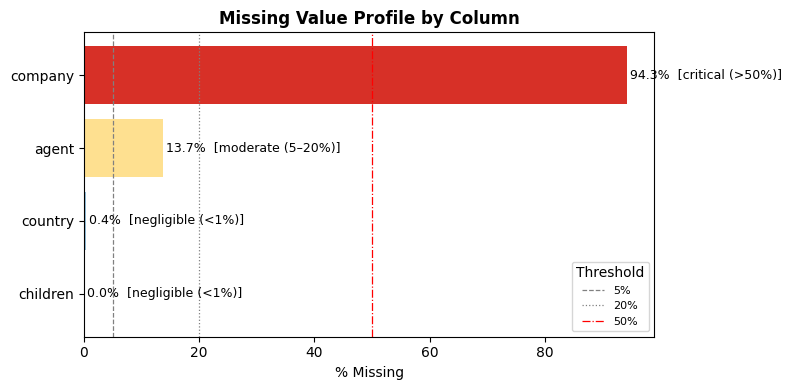

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

missing_plot = missing.sort_values("pct_missing", ascending=True)
palette = ["#d73027" if p > 50 else "#fc8d59" if p > 20 else
           "#fee090" if p > 5  else "#91bfdb"
           for p in missing_plot["pct_missing"]]

ax.barh(missing_plot["column"], missing_plot["pct_missing"], color=palette)
ax.set_xlabel("% Missing")
ax.set_title("Missing Value Profile by Column", fontweight="bold")
for thresh, ls, lbl in [(5, "--", "5%"), (20, ":", "20%"), (50, "-.", "50%")]:
    ax.axvline(thresh, color="gray" if thresh < 50 else "red",
               linestyle=ls, linewidth=0.9, label=lbl)
ax.legend(title="Threshold", fontsize=8)
for i, (_, row) in enumerate(missing_plot.iterrows()):
    ax.text(row["pct_missing"] + 0.5, i,
            f"{row['pct_missing']:.1f}%  [{row['severity']}]",
            va="center", fontsize=9)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "missing_values.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.2 Target Distribution

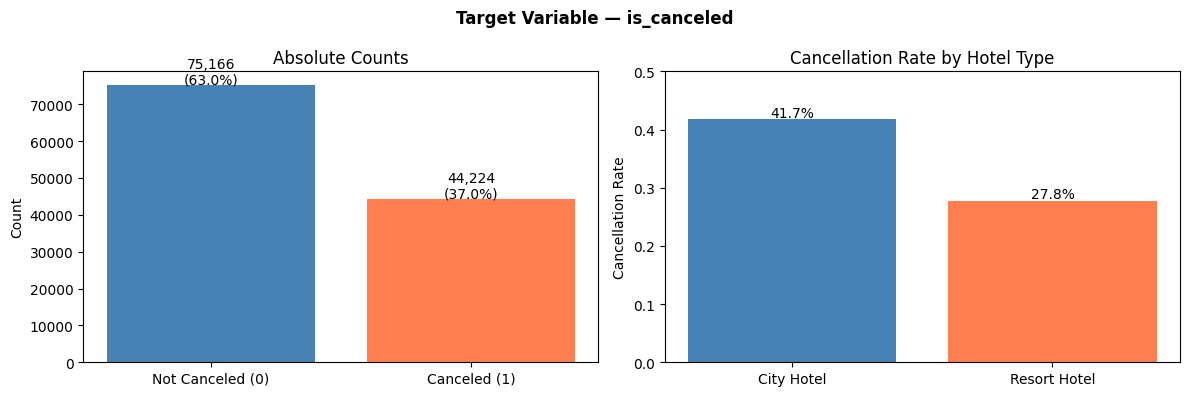

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Target Variable — is_canceled", fontsize=12, fontweight="bold")

vc = df["is_canceled"].value_counts()
axes[0].bar(["Not Canceled (0)", "Canceled (1)"], vc.values,
            color=["steelblue", "coral"])
axes[0].set_ylabel("Count")
axes[0].set_title("Absolute Counts")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 400, f"{v:,}\n({v/len(df):.1%})", ha="center", fontsize=10)

cr = df.groupby("hotel")["is_canceled"].mean().reset_index()
axes[1].bar(cr["hotel"], cr["is_canceled"], color=["steelblue", "coral"])
axes[1].set_ylabel("Cancellation Rate")
axes[1].set_title("Cancellation Rate by Hotel Type")
axes[1].set_ylim(0, 0.5)
for i, v in enumerate(cr["is_canceled"]):
    axes[1].text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.3 Numeric Feature Distributions by Cancellation Status

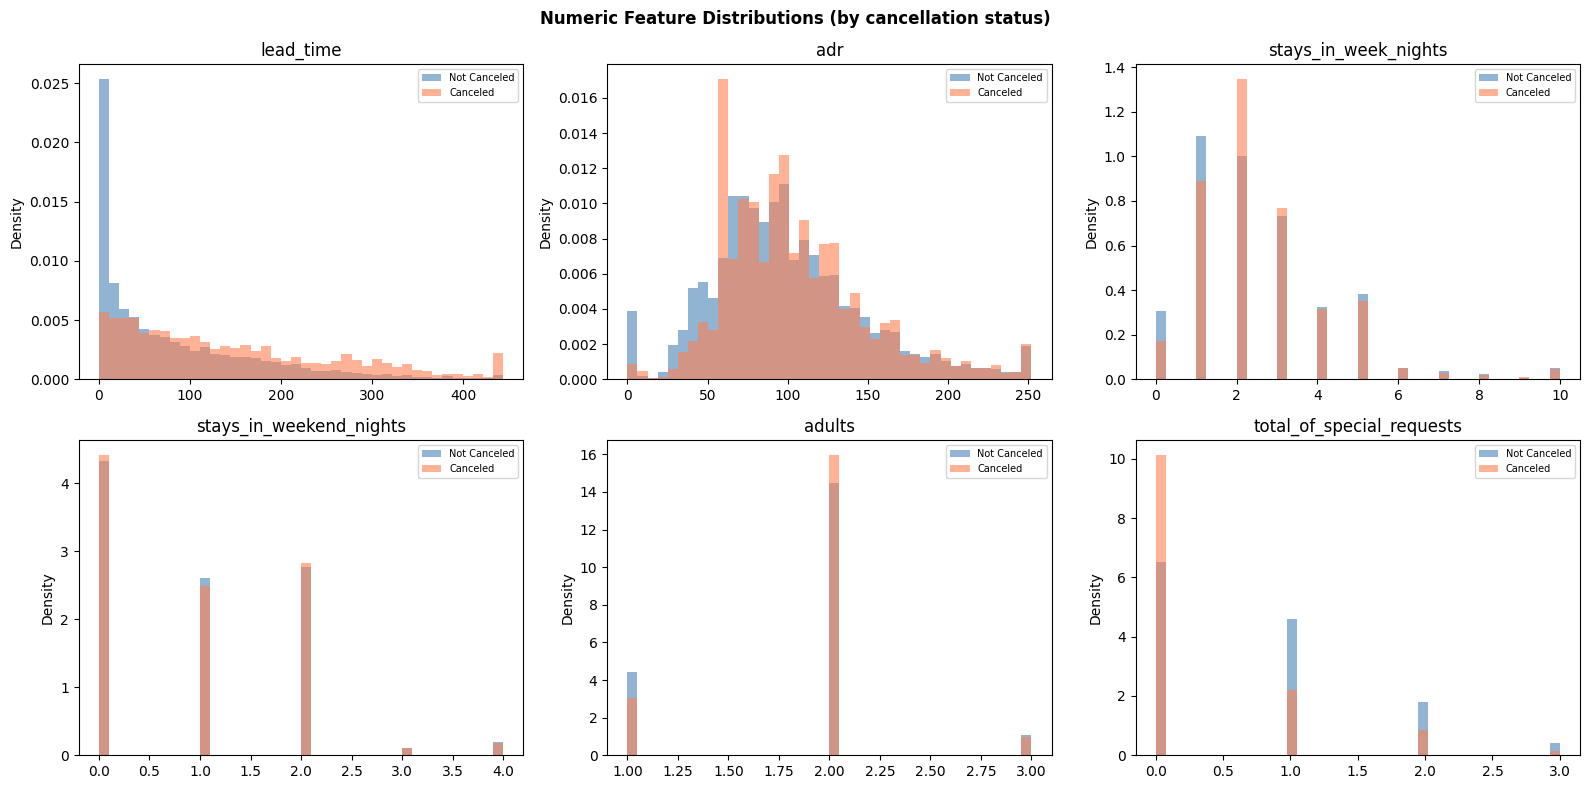

In [19]:
NUM_COLS = ["lead_time", "adr", "stays_in_week_nights",
            "stays_in_weekend_nights", "adults", "total_of_special_requests"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Numeric Feature Distributions (by cancellation status)",
             fontsize=12, fontweight="bold")

for ax, col in zip(axes.flatten(), NUM_COLS):
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    v0 = df.loc[df["is_canceled"] == 0, col].clip(lo, hi)
    v1 = df.loc[df["is_canceled"] == 1, col].clip(lo, hi)
    ax.hist(v0, bins=40, alpha=0.6, color="steelblue",
            density=True, label="Not Canceled")
    ax.hist(v1, bins=40, alpha=0.6, color="coral",
            density=True, label="Canceled")
    ax.set_title(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.4 Categorical Features — Cancellation Rates

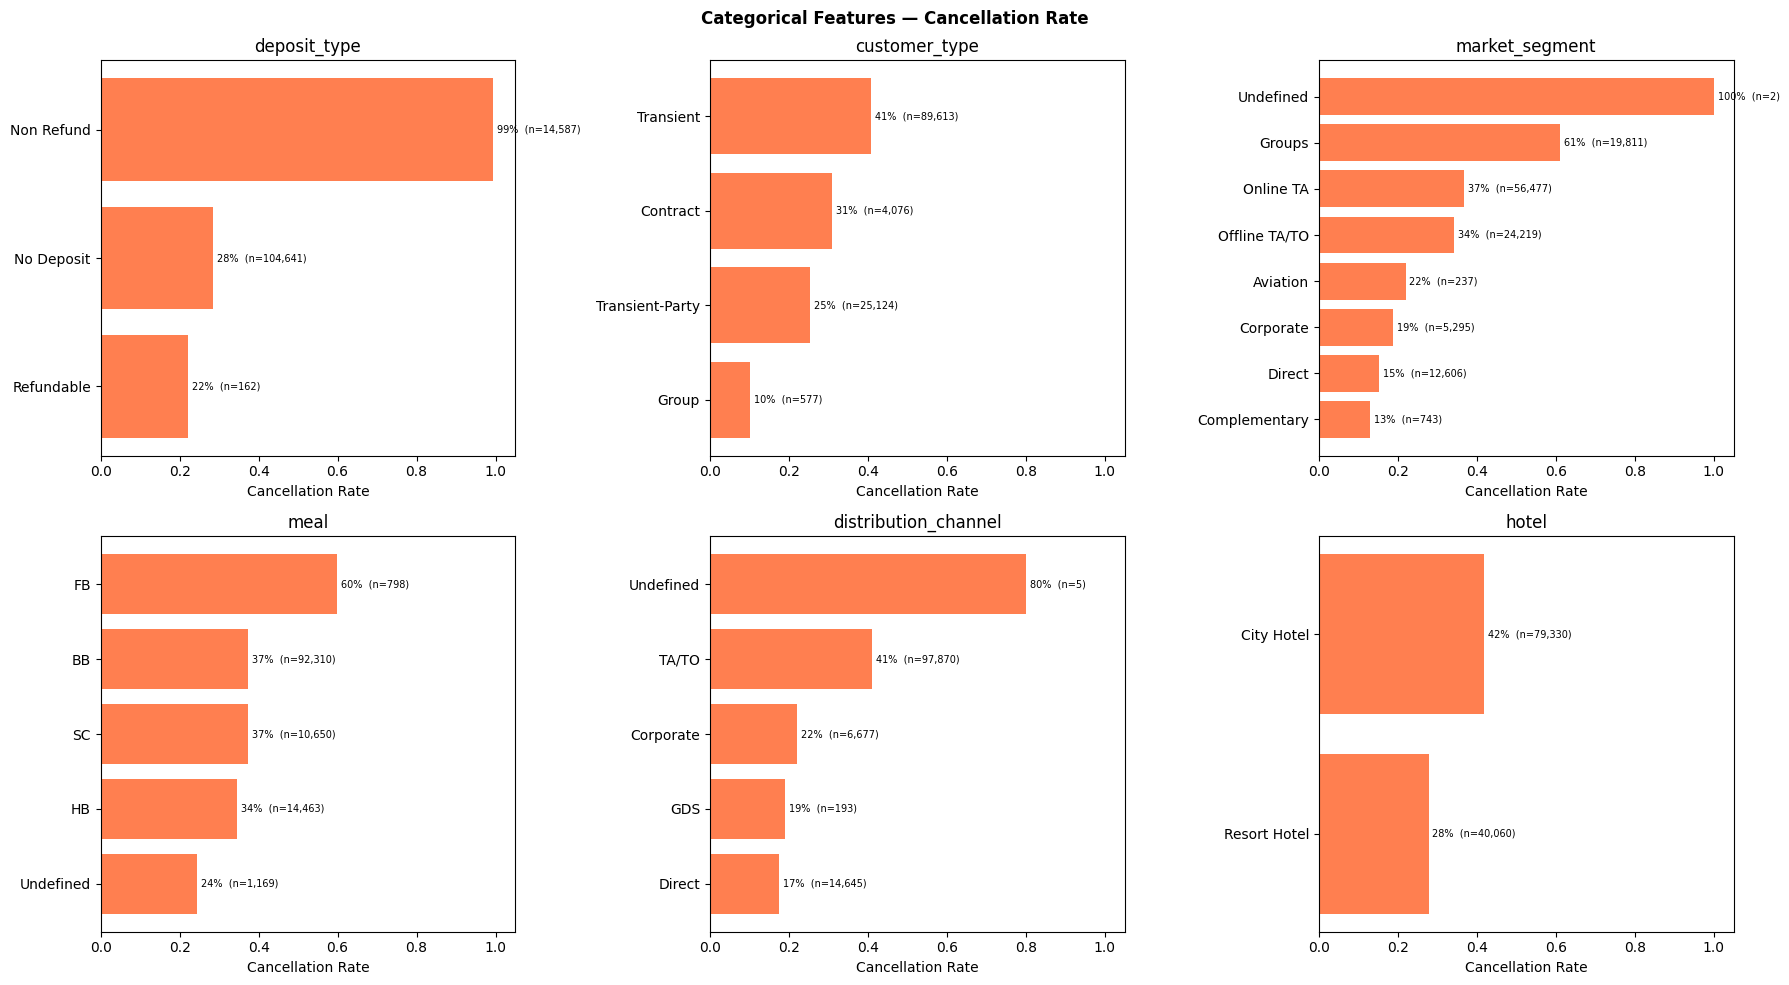

In [20]:
CAT_COLS = ["deposit_type", "customer_type", "market_segment",
            "meal", "distribution_channel", "hotel"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Categorical Features — Cancellation Rate", fontsize=12, fontweight="bold")

for ax, col in zip(axes.flatten(), CAT_COLS):
    stats = (
        df.groupby(col)["is_canceled"]
        .agg(["mean", "count"])
        .reset_index()
        .sort_values("mean", ascending=True)
    )
    bars = ax.barh(stats[col].astype(str), stats["mean"], color="coral")
    ax.set_xlabel("Cancellation Rate")
    ax.set_title(col)
    ax.set_xlim(0, 1.05)
    for bar, cnt in zip(bars, stats["count"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.0%}  (n={cnt:,})", va="center", fontsize=7)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "categorical_cancellation_rates.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.5 Leakage Confirmation — reservation_status

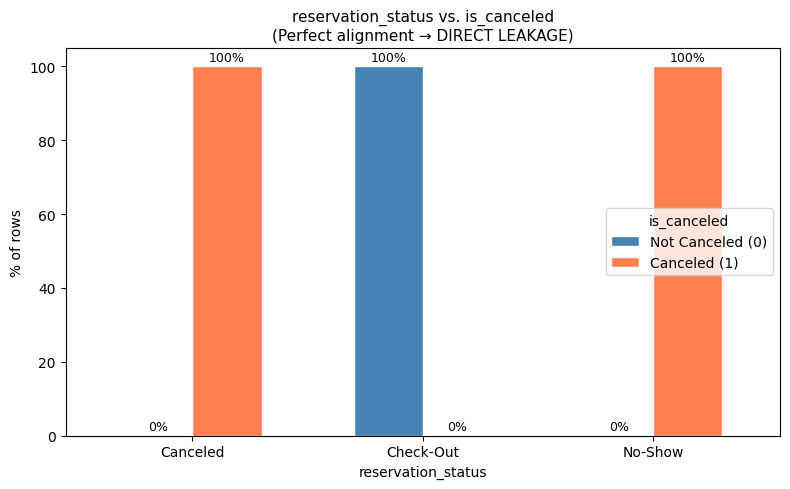

Confirmed: reservation_status encodes is_canceled perfectly.
It MUST be excluded before any modelling step.


In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

cross_pct = pd.crosstab(
    df["reservation_status"], df["is_canceled"], normalize="index"
) * 100
cross_pct.plot(kind="bar", ax=ax, color=["steelblue", "coral"],
               edgecolor="white", width=0.6)

ax.set_title("reservation_status vs. is_canceled\n"
             "(Perfect alignment → DIRECT LEAKAGE)", fontsize=11)
ax.set_ylabel("% of rows")
ax.set_xlabel("reservation_status")
ax.legend(["Not Canceled (0)", "Canceled (1)"], title="is_canceled")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", padding=2, fontsize=9)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "leakage_confirmation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Confirmed: reservation_status encodes is_canceled perfectly.")
print("It MUST be excluded before any modelling step.")


### 7.6 ADR Distribution & Outlier Profile

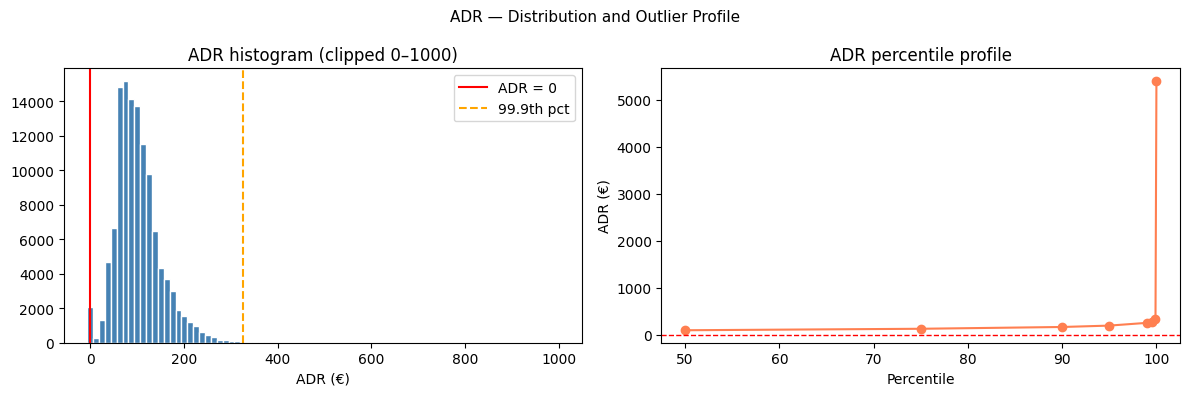

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("ADR — Distribution and Outlier Profile", fontsize=11)

axes[0].hist(df["adr"].clip(-10, 1000), bins=80, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linewidth=1.5, label="ADR = 0")
axes[0].axvline(df["adr"].quantile(0.999), color="orange",
                linewidth=1.5, linestyle="--", label="99.9th pct")
axes[0].set_title("ADR histogram (clipped 0–1000)")
axes[0].set_xlabel("ADR (€)")
axes[0].legend()

pct_vals = [50, 75, 90, 95, 99, 99.5, 99.9, 100]
adr_pcts = [df["adr"].quantile(p / 100) for p in pct_vals]
axes[1].plot(pct_vals, adr_pcts, marker="o", color="coral")
axes[1].set_title("ADR percentile profile")
axes[1].set_xlabel("Percentile")
axes[1].set_ylabel("ADR (€)")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "adr_profile.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Verification Assertions

In [23]:
errors = []

def check(condition, msg):
    status = "✓ PASS" if condition else "✗ FAIL"
    print(f"  [{status}]  {msg}")
    if not condition:
        errors.append(msg)

check(len(df) == 119390,                        "Dataset has 119,390 rows")
check(df.shape[1] == 32,                        "Dataset has 32 columns")
check(set(df["is_canceled"].unique()) == {0,1}, "is_canceled is binary {0, 1}")
check(df["company"].isna().sum() == 112593,     "company: 112,593 missing")
check(df["agent"].isna().sum()   == 16340,      "agent: 16,340 missing")
check(df["country"].isna().sum() == 488,        "country: 488 missing")
check(df["children"].isna().sum() == 4,         "children: 4 missing")
check(
    df.loc[df["reservation_status"]=="Canceled", "is_canceled"].min() == 1 and
    df.loc[df["reservation_status"]=="Canceled", "is_canceled"].max() == 1,
    "reservation_status='Canceled' always → is_canceled=1"
)
check(
    df.loc[df["reservation_status"]=="Check-Out", "is_canceled"].max() == 0,
    "reservation_status='Check-Out' always → is_canceled=0"
)
check(
    df["arrival_date_year"].min() == 2015 and
    df["arrival_date_year"].max() == 2017,
    "Data spans 2015–2017"
)
check(True, "No model was fitted (confirmed by design)")

print()
if errors:
    print(f"  {len(errors)} assertion(s) FAILED:")
    for e in errors: print(f"    - {e}")
    raise AssertionError("Verification failed — review findings above.")
else:
    print("  All assertions passed.")


  [✓ PASS]  Dataset has 119,390 rows
  [✓ PASS]  Dataset has 32 columns
  [✓ PASS]  is_canceled is binary {0, 1}
  [✓ PASS]  company: 112,593 missing
  [✓ PASS]  agent: 16,340 missing
  [✓ PASS]  country: 488 missing
  [✓ PASS]  children: 4 missing
  [✓ PASS]  reservation_status='Canceled' always → is_canceled=1
  [✓ PASS]  reservation_status='Check-Out' always → is_canceled=0
  [✓ PASS]  Data spans 2015–2017
  [✓ PASS]  No model was fitted (confirmed by design)

  All assertions passed.


## 9. Final Structured Summary

### A. Dataset Schema
- **119,390 bookings, 32 columns**, two hotel types (Resort / City), arrivals 2015–2017
- Target: `is_canceled` (binary, **37.0% positive rate**)
- Features span booking logistics, guest profile, room details, and financials

### B. Missing Value Assessment

| Column | N missing | % | Mechanism | Action |
|---|---|---|---|---|
| `company` | 112,593 | **94.3%** | MAR (structural) | Drop; use `has_company` flag |
| `agent` | 16,340 | **13.7%** | MAR (by channel) | `has_agent` flag + sentinel |
| `country` | 488 | 0.4% | Likely MCAR | Mode / `'Unknown'` |
| `children` | 4 | 0.003% | Entry error | Fill with 0 |

### C. Data Quality Issues

| Issue | N | Severity |
|---|---|---|
| Exact duplicate rows | 31,994 (26.8%) | Medium |
| Zero-guest bookings | 180 | High |
| Zero-night non-cancelled | 680 | Medium |
| Negative ADR | 1 | High |
| Extreme ADR (>5000) | 1 | Low |
| `meal='Undefined'` | 1,169 | Low |
| `lead_time` > 500 days | 481 | Low |

### D. Leakage & Risk Flags

| Variable | Risk Type | Action |
|---|---|---|
| `reservation_status` | **DIRECT LEAKAGE** | Drop before any split |
| `reservation_status_date` | **DIRECT LEAKAGE** | Drop before any split |
| `assigned_room_type` | Indirect / temporal | Retain; monitor importance |
| `booking_changes` | Indirect / temporal | Retain; monitor importance |
| `adr` | Indirect / temporal | Retain with caution |

**Structural:** temporal bias → chronological split mandatory; high cardinality in `country` / `agent`.

### E. Preprocessing Strategy (10 steps)
1. Drop `reservation_status`, `reservation_status_date`
2. Create `has_agent`, `has_company` flags; drop `company`
3. Fix impossible values (zero guests, negative ADR)
4. Remove exact duplicates
5. Impute: `children→0`, `country→mode`, `agent→flag`
6. Engineer features: `total_nights`, `total_guests`, `cancel_rate_history`, `room_changed`, `weekend_ratio`
7. Encode: OHE (low-cardinality); frequency-group (high-cardinality)
8. Scale: `StandardScaler` inside sklearn `Pipeline`
9. **Chronological** 80/20 split; `StratifiedKFold(n_splits=5)` on train only
10. Metrics: ROC-AUC, PR-AUC, F1-macro

---
*Task 1 complete. No models were trained or evaluated.*
